### import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow import keras
from keras.layers import Flatten,Dense
from keras.models import Sequential

In [2]:
df=pd.read_excel("HR_comma_sep.xlsx")
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
1718,0.44,0.54,2,133,3,0,1,0,technical,low
12782,0.72,1.00,4,245,5,0,1,0,sales,low
12223,0.87,0.90,5,252,5,0,1,0,IT,low
7344,0.45,0.71,2,172,2,0,0,0,sales,low
8348,0.80,0.78,3,251,3,0,0,0,sales,high


In [3]:
df["dept"].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [4]:
df["salary"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [5]:
new_df=pd.get_dummies(df,["dept","salary"],drop_first=True)

In [6]:
new_df.sample(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,salary_low,salary_medium
7301,0.52,0.63,3,230,2,0,0,0,False,False,False,False,False,False,False,True,False,False,True
9913,0.42,0.58,2,140,3,0,0,0,False,False,False,False,False,False,False,False,False,True,False
10228,0.63,0.70,6,141,3,1,0,0,False,False,False,False,True,False,False,False,False,False,True
11956,0.85,0.87,4,152,7,0,0,0,False,False,False,False,False,False,True,False,False,True,False
6699,0.79,0.86,5,270,2,0,0,0,False,False,False,True,False,False,False,False,False,True,False
12803,0.59,0.72,4,168,4,0,0,0,False,False,False,True,False,False,False,False,False,False,True
8512,0.55,0.88,3,173,3,1,0,0,False,False,False,False,False,False,False,False,True,True,False
10899,0.89,0.91,3,233,2,0,0,0,False,False,False,False,False,False,False,False,False,False,True
1259,0.45,0.48,2,138,3,0,1,0,False,False,False,False,False,False,False,False,True,True,False
13582,0.94,0.59,3,151,2,0,0,0,False,False,False,False,False,False,True,False,False,True,False


In [7]:
print("df shape:",df.shape)
print("new df shape",new_df.shape)


df shape: (14999, 10)
new df shape (14999, 19)


In [8]:
x=new_df.drop("left",axis=1)
y=new_df["left"]


In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.29)

In [10]:
scaled=MinMaxScaler()
x_train_scaled=scaled.fit_transform(x_train)
x_test_scaled=scaled.fit_transform(x_test)

In [11]:
model=Sequential()

In [12]:
model.add(Flatten(input_shape=(x_train.shape[1],)))
model.add(Dense(128,activation="relu"))
model.add(Dense(64,activation="relu"))
model.add(Dense(32,activation="relu"))
model.add(Dense(16,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

C:\Users\fahadch\anaconda4\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 18)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss = "binary_crossentropy",optimizer = "adam",metrics=["accuracy"])


In [15]:
history=model.fit(x_train_scaled,y_train,epochs=150,validation_split=0.2)

Epoch 1/150
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7898 - loss: 0.4469 - val_accuracy: 0.8709 - val_loss: 0.2983
Epoch 2/150
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9142 - loss: 0.2278 - val_accuracy: 0.9427 - val_loss: 0.1751
Epoch 3/150
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9464 - loss: 0.1627 - val_accuracy: 0.9592 - val_loss: 0.1495
Epoch 4/150
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9486 - loss: 0.1528 - val_accuracy: 0.9582 - val_loss: 0.1415
Epoch 5/150
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9555 - loss: 0.1406 - val_accuracy: 0.9601 - val_loss: 0.1455
Epoch 6/150
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9586 - loss: 0.1337 - val_accuracy: 0.9629 - val_loss: 0.1358
Epoch 7/150
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9604 - loss: 0.1249 - val_accuracy: 0.9592 - val_loss: 0.1304
Epoch 8/150
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9627 - loss: 0.1224 - val_accu

In [16]:
y_pred=model.predict(x_test_scaled)
y_pred

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[4.8785150e-11],
       [2.3244771e-10],
       [2.7907785e-04],
       ...,
       [1.0690431e-05],
       [9.9988580e-01],
       [2.0562049e-03]], shape=(4350, 1), dtype=float32)

In [17]:
y_pred_class=np.where(y_pred>0.5,1,0)

In [18]:
acc=accuracy_score(y_test,y_pred_class)
print("accuracy of the model:",acc)

accuracy of the model: 0.965287356321839


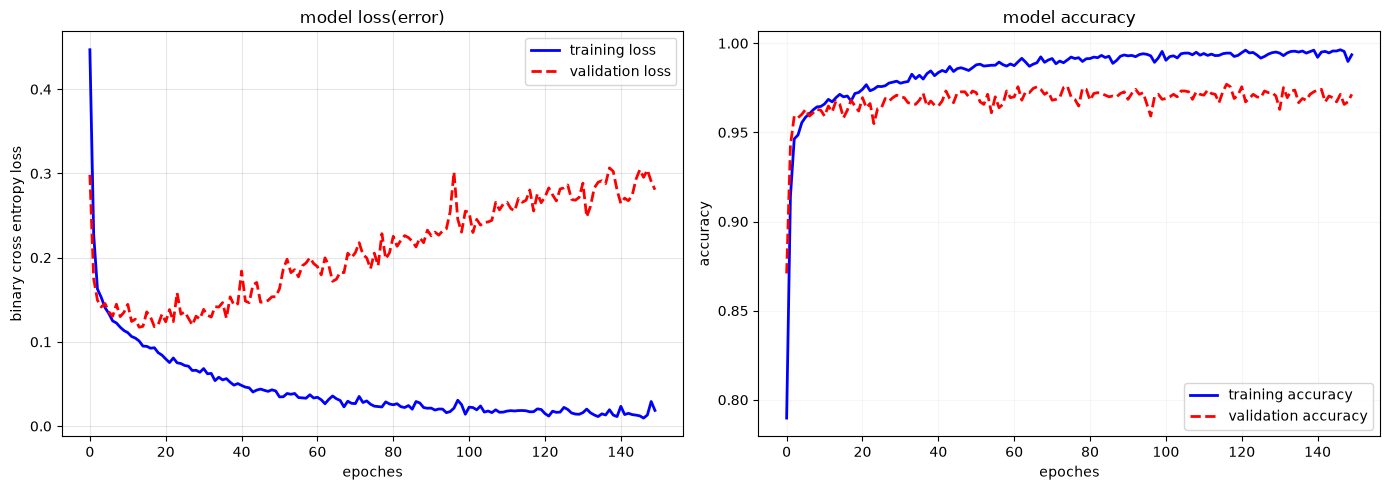

In [19]:
fig,(ax1,ax2)=plt.subplots(1,2, figsize=(14, 5))
ax1.plot(history.history["loss"],label="training loss",color="blue",linewidth=2)
ax1.plot(history.history["val_loss"],label="validation loss",color="red",linewidth=2,linestyle="--")
ax1.set_title("model loss(error)")
ax1.set_xlabel("epoches")
ax1.set_ylabel("binary cross entropy loss")
ax1.legend()
ax1.grid(True,alpha=0.3)
ax2.plot(history.history["accuracy"],label="training accuracy",color="blue",linewidth=2)
ax2.plot(history.history["val_accuracy"],label="validation accuracy",color="red",linewidth=2,linestyle="--")
ax2.set_title("model accuracy")
ax2.set_xlabel("epoches")
ax2.set_ylabel("accuracy")
ax2.legend()
ax2.grid(True,alpha=0.1)
plt.tight_layout()
plt.show()



